In [1]:
import pandas as pd
import numpy as np

In [2]:
high_mass_centrals_df = pd.read_parquet ('../high_mass_central_df_annuli_revised.parquet')

In [3]:
high_mass_centrals_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
0,0.0,0.010883,10.939674,-1.120602,7.966769,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
1,0.0,0.032649,10.494615,-1.556470,7.919378,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
2,0.0,0.054415,9.982732,-2.017950,7.934402,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
3,0.0,0.076182,9.739688,-2.263846,7.927703,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
4,0.0,0.097948,9.594884,-2.389380,7.926022,1,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54984,594444.0,0.169860,9.321200,-2.636930,6.265163,1,0.000000,2.942021,0.006637,0,89.968681,0.066943,2.062991e+04,0.000000e+00,19.274660,19.981537,-0.021362,0.070190,2.062991e+04
54985,594444.0,0.509579,8.999712,-1.776677,6.709038,0,0.000000,2.942021,0.006637,0,89.968681,0.066943,2.062991e+04,0.000000e+00,19.274660,19.981537,-0.021362,0.070190,2.062991e+04
54986,594444.0,0.849298,8.734355,-3.316755,7.059817,1,0.000000,2.942021,0.006637,0,89.968681,0.066943,2.062991e+04,0.000000e+00,19.274660,19.981537,-0.021362,0.070190,2.062991e+04
54987,594444.0,1.189017,8.498129,-3.504491,6.857232,1,0.000000,2.942021,0.006637,0,89.968681,0.066943,2.062991e+04,0.000000e+00,19.274660,19.981537,-0.021362,0.070190,2.062991e+04


In [4]:
# # calculating star forming efficiency (SFE) and gas fraction 
# low_mass_satellite_df['SFE'] = 10**(low_mass_satellite_df['avg_SFR'] - low_mass_satellite_df['avg_gas_mass'])
# low_mass_satellite_df['f_gas'] = 10**(low_mass_satellite_df['avg_gas_mass'] - low_mass_satellite_df['avg_s_mass'])

In [5]:
# # remove the rows where the sfr_indicator is 0.0 -> implies artificially imposed minimum
# low_mass_satellite_df = low_mass_satellite_df[low_mass_satellite_df['sfr_indicator'] != 0.0]
# low_mass_satellite_df

In [6]:
# star forming quenching vector value = 0
high_mass_centrals_df = high_mass_centrals_df[high_mass_centrals_df['quenching_vector'] != 1]
high_mass_centrals_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
0,0.0,0.010883,10.939674,-1.120602,7.966769,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
1,0.0,0.032649,10.494615,-1.556470,7.919378,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
2,0.0,0.054415,9.982732,-2.017950,7.934402,0,19187.548828,370.558472,0.700941,0,603.875061,0.456323,5.678228e+08,6.904271e-310,38878.035156,102677.912949,0.982283,0.205462,5.678228e+08
644,17185.0,0.004284,10.488805,-1.521891,7.630356,0,0.000000,228.544006,0.556990,0,594.971252,1.667390,1.161822e+09,3.915732e+08,33180.992188,4603.822492,1.289787,0.244981,1.553395e+09
645,17185.0,0.012853,10.220413,-1.775405,7.611776,0,0.000000,228.544006,0.556990,0,594.971252,1.667390,1.161822e+09,3.915732e+08,33180.992188,4603.822492,1.289787,0.244981,1.553395e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48949,562410.0,1.119661,8.413935,-1.564219,7.630833,0,0.000000,2.275262,0.004635,0,82.065796,1.607175,2.461513e+03,1.389233e-316,34.545956,4.056387,-0.793238,0.072292,2.461513e+03
48950,562410.0,1.439564,8.239394,-2.031924,7.606252,0,0.000000,2.275262,0.004635,0,82.065796,1.607175,2.461513e+03,1.389233e-316,34.545956,4.056387,-0.793238,0.072292,2.461513e+03
48951,562410.0,1.759467,7.978919,-2.663112,7.356964,0,0.000000,2.275262,0.004635,0,82.065796,1.607175,2.461513e+03,1.389233e-316,34.545956,4.056387,-0.793238,0.072292,2.461513e+03
49066,563241.0,0.172311,9.596712,-2.317702,7.677955,0,0.212526,2.357653,0.008387,0,82.442406,0.016811,5.532517e+05,0.000000e+00,38.519566,54.214864,0.083967,0.068477,5.532517e+05


In [7]:
high_mass_centrals_df.shape

(14646, 19)

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import RobustScaler

# 'BHMass', 'BHCum_QM', 'Mhalo', 'overdens', and 'bulge' are the features wer are testing
high_mass_centrals_df = high_mass_centrals_df.drop(columns=["class", "BH_cumQM", "BH_cumRM", "global_SFRs", "gas_mass","avg_gas_mass", "quenching_vector", "Bfld", "veldisp", "BH_AGN"])


<Axes: >

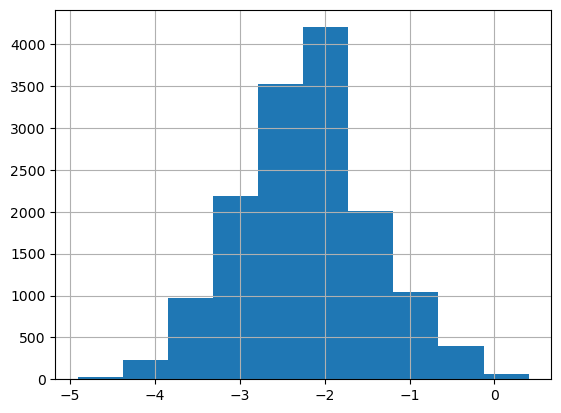

In [9]:
high_mass_centrals_df['avg_SFR'].hist()

In [10]:
# this indicates that there are more instances of the delta rate on the left

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

galaxy_ids = high_mass_centrals_df['subID']

feature_importances_list = []
feature_names = None
test_mses = []
train_mses = []


for seed in range(10):
    # split galaxies into 50% training and 50% testing
    unique_galaxies = np.unique(high_mass_centrals_df['subID'])
    train_galaxies, test_galaxies = train_test_split(unique_galaxies, test_size=0.5, random_state=seed)

    # assign spaxels based on galaxy split
    train_data = high_mass_centrals_df[high_mass_centrals_df['subID'].isin(train_galaxies)]
    test_data = high_mass_centrals_df[high_mass_centrals_df['subID'].isin(test_galaxies)]

    X_train, y_train = train_data.drop(columns=['avg_SFR', 'subID']), train_data['avg_SFR']
    X_test, y_test = test_data.drop(columns=['avg_SFR', 'subID']), test_data['avg_SFR']
    
    
    if feature_names is None:
        feature_names = X_train.columns.tolist()

    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    cv = KFold(n_splits=5, shuffle=True, random_state=seed)

    # XGBoost Regressor
    xgb_regressor = XGBRegressor(random_state=seed, n_jobs=-1)

    param_grid = {
    'n_estimators': [300],
    'max_depth': [2],
    'learning_rate': [0.01],
    'subsample': [0.6],
    'colsample_bytree': [1.0],
    'min_child_weight': [40,50],     
    'reg_alpha': [5],             
    'reg_lambda': [20]            
    }



    grid_search = GridSearchCV(
    estimator=xgb_regressor, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error',
    n_jobs=-1, 
    verbose=2
    )

    grid_search.fit(X_train_scaled, y_train)

    best_xg_regressor = grid_search.best_estimator_

    best_xg_regressor.fit(X_train_scaled, y_train)
    
    y_train_pred = best_xg_regressor.predict(X_train_scaled)
    y_test_pred = best_xg_regressor.predict(X_test_scaled)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_mses.append(train_mse)
    test_mses.append(test_mse)
    
    feature_importances_list.append(best_xg_regressor.feature_importances_)
#     print(random_search.best_params_)
    print(f"Run {seed+1}: Train MSE = {train_mse:.4f}, Test MSE = {test_mse:.4f}")

print("\nAverage MSE over 10 runs:")
print(f"Train MSE: Mean = {np.mean(train_mses):.4f}, Std = {np.std(train_mses):.4f}")
print(f"Test MSE:  Mean = {np.mean(test_mses):.4f}, Std = {np.std(test_mses):.4f}")


Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=2, min_child_weight=40, n_estimators=300, reg_alpha=5, reg_lambda=20, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=2, min_child_weight=40, n_estimators=300, reg_alpha=5, reg_lambda=20, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=2, min_child_weight=40, n_estimators=300, reg_alpha=5, reg_lambda=20, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=2, min_child_weight=40, n_estimators=300, reg_alpha=5, reg_lambda=20, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=2, min_child_weight=40, n_estimators=300, reg_alpha=5, reg_lambda=20, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=2, min_child_weight=50, n_estimators=300, reg_alpha=5,


=== Average Feature Importances ===
      Feature  Mean Importance   Std Dev
1  avg_s_mass         0.357846  0.038472
6       bulge         0.209693  0.019148
3      BHMass         0.177133  0.018294
4       Mhalo         0.112454  0.030478
2      s_mass         0.071259  0.018268
0   bin_radii         0.039460  0.020148
5    overdens         0.032154  0.043420


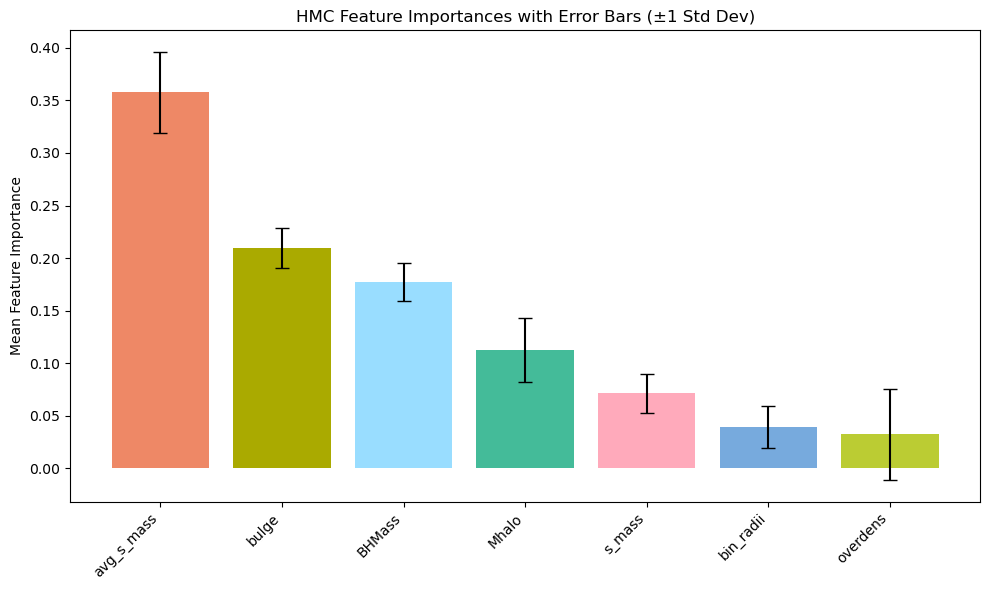

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
feature_colors = {
    'bin_radii': '#77AADD',
    'avg_s_mass': '#EE8866',
    's_mass': '#FFAABB',
    'BHMass': '#99DDFF',
    'Mhalo': '#44BB99',
    'overdens': '#BBCC33',
    'bulge': '#AAAA00',
    'BH_AGN': '#DDDDDD',
}

# importances + stds across 10 runs
importances_array = np.array(feature_importances_list)
importance_means = np.mean(importances_array, axis=0)
importance_stds = np.std(importances_array, axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean Importance': importance_means,
    'Std Dev': importance_stds
}).sort_values(by='Mean Importance', ascending=False)

print("\n=== Average Feature Importances ===")
print(importance_df)

colors = [feature_colors[feat] for feat in importance_df['Feature']]
# Plot
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Mean Importance'], yerr=importance_df['Std Dev'], capsize=5, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean Feature Importance")
plt.title("HMC Feature Importances with Error Bars (±1 Std Dev)")
plt.tight_layout()
plt.show()

In [13]:
high_mass_centrals_df.corr()

,subID,bin_radii,avg_s_mass,avg_SFR,s_mass,BHMass,Mhalo,overdens,bulge
subID,1.000000,0.028723,-0.062529,0.339596,-0.814720,-0.792505,-0.705943,-0.165737,-0.493760
bin_radii,0.028723,1.000000,-0.853607,-0.472958,-0.055812,-0.061418,-0.047401,0.000603,0.021914
avg_s_mass,-0.062529,-0.853607,1.000000,0.531191,0.054049,0.054467,0.007626,0.035458,-0.028699
avg_SFR,0.339596,-0.472958,0.531191,1.000000,-0.256556,-0.253917,-0.215316,0.060379,-0.484473
s_mass,-0.814720,-0.055812,0.054049,-0.256556,1.000000,0.984213,0.918228,0.180550,0.366290
BHMass,-0.792505,-0.061418,0.054467,-0.253917,0.984213,1.000000,0.899892,0.150542,0.359881
Mhalo,-0.705943,-0.047401,0.007626,-0.215316,0.918228,0.899892,1.000000,0.288685,0.274516
overdens,-0.165737,0.000603,0.035458,0.060379,0.180550,0.150542,0.288685,1.000000,0.011631
bulge,-0.493760,0.021914,-0.028699,-0.484473,0.366290,0.359881,0.274516,0.011631,1.000000


In [14]:
import os
# Define your directory and file name
directory = 'xg_regression_outputs'
filename = 'hmc_xg_reg.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
importance_df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

DataFrame saved to xg_regression_outputs/hmc_xg_reg.csv


In [15]:
train_mean = round(np.mean(train_mses), 2)
test_mean = round(np.mean(test_mses), 2)

df = pd.DataFrame({
    'Train MSE': [train_mean],
    'Test MSE': [test_mean]
})

print(df)
import os
# Define your directory and file name
directory = 'xg_regression_outputs'
filename = 'hmc_xg_reg_mse.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

   Train MSE  Test MSE
0       0.25      0.27
DataFrame saved to xg_regression_outputs/hmc_xg_reg_mse.csv
